<a href="https://colab.research.google.com/github/LunaGar1/Pratica2-Vision-e-IA/blob/main/P2_reto5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importar librerías

In [1]:
!pip install mahotas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mahotas: filename=mahotas-1.4.18-cp313-cp313-linux_x86_64.whl size=5084994 sha256=566a9423bd7277af54388e896c8e1aaa3c334f239e608458b2955e61de64b27e
  Stored in directory: /root/.cache/pip/wheels/78/3a/c8/2a34e8fe7affed12f7b7c9d4e3ef0ff249f18b00667ee67cc0
Successfully built mahotas


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import os
import random
import pandas as pd
import mahotas
import matplotlib.pyplot as plt
from scipy.stats import mode
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Leer imagen y traer el data set

In [13]:
base_path = '/content/drive/MyDrive/VisionComputadorIA/'
folder = '3scenes/'
subfolders = ['coast', 'forest', 'highway']

paths = []
labels = []

feat_rgb = []
feat_hsv = []
feat_haralick = []

for subfolder in subfolders:
    files = [f for f in os.listdir(base_path + folder + subfolder) if f.endswith('.jpg')]
    for file in files:
        path = base_path + folder + subfolder + '/' + file
        paths.append(path)
        labels.append(subfolder)

        img = cv2.imread(path, cv2.IMREAD_COLOR)

        # RGB
        B, G, R = cv2.split(img)
        feat_rgb.append([np.mean(R), np.mean(G), np.mean(B),
                          np.std(R), np.std(G), np.std(B)])

        # HSV
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        H, S, V = cv2.split(hsv)
        feat_hsv.append([np.mean(H), np.mean(S), np.mean(V),
                          np.std(H), np.std(S), np.std(V)])

        # Haralick (texturas)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feat_haralick.append(mahotas.features.haralick(gray).mean(axis=0))

feat_rgb = np.array(feat_rgb)
feat_hsv = np.array(feat_hsv)
feat_haralick = np.array(feat_haralick)

# Convertir a DataFrames para inspección más legible
df_rgb = pd.DataFrame(feat_rgb, columns=['R_mean','G_mean','B_mean','R_std','G_std','B_std'])
df_hsv = pd.DataFrame(feat_hsv, columns=['H_mean','S_mean','V_mean','H_std','S_std','V_std'])
df_haralick = pd.DataFrame(feat_haralick, columns=[f'haralick_{i}' for i in range(feat_haralick.shape[1])])

df_rgb['label'] = labels
df_hsv['label'] = labels
df_haralick['label'] = labels


print(df_rgb.groupby('label').mean())

             R_mean      G_mean      B_mean      R_std      G_std      B_std
label                                                                       
coast    112.927729  117.883239  123.603075  55.219803  48.915799  47.746338
forest    96.020505  102.294135   76.004367  54.653882  54.754523  52.492257
highway  118.232626  133.439404  136.434676  46.543035  50.175333  59.499015


In [14]:
le = LabelEncoder()
labels = le.fit_transform(labels)
print(le.classes_)

['coast' 'forest' 'highway']


### Definir combinaciones de características






In [15]:
feature_sets = {
    'RGB': feat_rgb,
    'HSV': feat_hsv,
    'Haralick': feat_haralick,
    'RGB+HSV': np.hstack([feat_rgb, feat_hsv]),
    'RGB+Haralick': np.hstack([feat_rgb, feat_haralick]),
    'HSV+Haralick': np.hstack([feat_hsv, feat_haralick]),
    'RGB+HSV+Haralick': np.hstack([feat_rgb, feat_hsv, feat_haralick]),
}

### Definir modelos

In [16]:
def get_models():
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'DecisionTree': DecisionTreeClassifier(),
        'RandomForest': RandomForestClassifier(),
        'GaussianNB': GaussianNB(),
        'SVC': SVC(),
        'KMeans': KMeans(n_clusters=3, random_state=28, n_init=10),
        'MLP': MLPClassifier(max_iter=1000),
        'KNN': KNeighborsClassifier(),
        'GradientBoosting': GradientBoostingClassifier(),
    }

### Entrenar y evaluar modelos

In [17]:
results = []

for feat_name, X in feature_sets.items():
    X = np.array(X)
    trainX, testX, trainY, testY = train_test_split(
        X, labels, test_size=0.25, random_state=42
    )

    scaler = StandardScaler()
    trainX_s = scaler.fit_transform(trainX)
    testX_s = scaler.transform(testX)

    models = get_models()

    for model_name, model in models.items():
        try:
            if model_name == 'KMeans':
                model.fit(trainX_s)
                preds = model.predict(testX_s)
                mapped = np.zeros_like(preds)
                for cluster in np.unique(preds):
                    mask = (preds == cluster)
                    if mask.sum() > 0:
                        mapped[mask] = mode(testY[mask], keepdims=True)[0]
                acc = accuracy_score(testY, mapped)
            else:
                model.fit(trainX_s, trainY)
                preds = model.predict(testX_s)
                acc = accuracy_score(testY, preds)

            results.append({'Features': feat_name, 'Modelo': model_name,
                             'Accuracy': round(acc * 100, 2)})
        except Exception as e:
            results.append({'Features': feat_name, 'Modelo': model_name,
                             'Accuracy': None})
            print(f'Error en {model_name} / {feat_name}: {e}')

df_results = pd.DataFrame(results)
#df_results

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Comparar resultados

In [18]:
pivot = df_results.pivot(index='Modelo', columns='Features', values='Accuracy')
pivot

Features,HSV,HSV+Haralick,Haralick,RGB,RGB+HSV,RGB+HSV+Haralick,RGB+Haralick
Modelo,,,,,,,
DecisionTree,69.17,81.25,82.50,72.92,71.67,83.33,79.58
GaussianNB,66.25,81.25,74.58,63.75,66.25,80.83,81.67
GradientBoosting,71.67,86.25,83.33,81.67,79.17,88.75,88.33
KMeans,51.67,69.58,70.42,47.50,49.17,67.50,68.75
KNN,77.50,83.75,80.83,73.75,77.92,86.25,84.58
LogisticRegression,70.00,84.17,79.58,77.08,78.33,87.50,85.42
MLP,80.00,91.25,86.25,77.50,83.75,88.33,90.42
RandomForest,75.83,90.42,84.58,78.75,82.08,90.42,88.75
SVC,77.92,86.67,81.25,78.33,82.50,87.50,87.92


## Mejor modelo


In [19]:
mejor_fila = df_results.loc[df_results['Accuracy'].idxmax()]
print('Mejor combinación encontrada:')
print(mejor_fila)

Mejor combinación encontrada:
Features    HSV+Haralick
Modelo               MLP
Accuracy           91.25
Name: 51, dtype: object


In [20]:
mejor_feat = mejor_fila['Features']
mejor_modelo_nombre = mejor_fila['Modelo']

X = np.array(feature_sets[mejor_feat])
trainX, testX, trainY, testY = train_test_split(X, labels, test_size=0.25, random_state=42)
scaler = StandardScaler()
trainX_s = scaler.fit_transform(trainX)
testX_s = scaler.transform(testX)

modelo_final = get_models()[mejor_modelo_nombre]
modelo_final.fit(trainX_s, trainY)
preds = modelo_final.predict(testX_s)

print(f'Modelo: {mejor_modelo_nombre} | Features: {mejor_feat}\n')
print(classification_report(testY, preds, target_names=le.classes_))

Modelo: MLP | Features: HSV+Haralick

              precision    recall  f1-score   support

       coast       0.89      0.87      0.88        92
      forest       0.98      0.95      0.96        85
     highway       0.82      0.87      0.85        63

    accuracy                           0.90       240
   macro avg       0.90      0.90      0.90       240
weighted avg       0.90      0.90      0.90       240



## Prueba de imagen aleatoria

Path: /content/drive/MyDrive/VisionComputadorIA/3scenes/coast/coast_sun1.jpg
Predicted class: coast


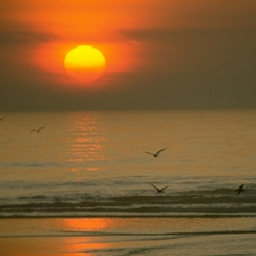

In [21]:
rand_pos = random.randint(0, len(paths) - 1)
print('Path:', paths[rand_pos])

img = cv2.imread(paths[rand_pos])

# Recalcular features según la combinación ganadora
B, G, R = cv2.split(img)
rgb_f = [np.mean(R), np.mean(G), np.mean(B), np.std(R), np.std(G), np.std(B)]

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)
hsv_f = [np.mean(H), np.mean(S), np.mean(V), np.std(H), np.std(S), np.std(V)]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
har_f = list(mahotas.features.haralick(gray).mean(axis=0))

# Ajustar según mejor_feat (ejemplo si fue RGB+Haralick)
feature_map = {'RGB': rgb_f, 'HSV': hsv_f, 'Haralick': har_f,
               'RGB+HSV': rgb_f+hsv_f, 'RGB+Haralick': rgb_f+har_f,
               'HSV+Haralick': hsv_f+har_f, 'RGB+HSV+Haralick': rgb_f+hsv_f+har_f}

feature = np.array(feature_map[mejor_feat]).reshape(1, -1)
feature_s = scaler.transform(feature)

pred = modelo_final.predict(feature_s)
print('Predicted class:', le.classes_[pred][0])
cv2_imshow(img)

## Conclusiones
1. Las características de textura (Haralick) fueron el factor más determinante. Usado solo, Haralick (81.67%) superó tanto a RGB (76.02%) como a HSV (76.53%), y cualquier combinación que lo incluyera mejoró notablemente el accuracy. Esto se debe a que Haralick captura patrones espaciales entre píxeles vecinos (rugosidad, homogeneidad), algo que el color por sí solo no puede representar.
2. Combinar color y textura dio los mejores resultados, pero con mejoras marginales al sumar más canales de color. El mejor promedio fue RGB+HSV+Haralick (85.97%), muy cerca de HSV+Haralick (85.14%) y RGB+Haralick (85.05%). En cambio, RGB+HSV sin textura (77.96%) apenas mejoró sobre usarlos por separado, mostrando que RGB y HSV aportan información redundante entre sí.
3. Los modelos capaces de capturar relaciones no lineales tuvieron el mejor desempeño: MLP (88.69% promedio), RandomForest (87.02%) y SVC (86.19%) superaron consistentemente a los modelos lineales. El mejor resultado individual fue MLP con HSV+Haralick (92.92%).
4. Los modelos más simples o con supuestos restrictivos tuvieron techos más bajos: LogisticRegression (82.98%) y DecisionTree (79.76%) por su naturaleza lineal o tendencia al sobreajuste; GaussianNB (75.83%) por asumir independencia entre características, algo que no se cumple entre los descriptores usados.
5. KMeans tuvo el peor desempeño (61.91% promedio), lo cual era esperado: al ser no supervisado, no usa las etiquetas durante el entrenamiento, confirmando que este es un problema que se beneficia claramente de un enfoque supervisado.

**Conclusión general:** agregar información de textura (Haralick) al color fue la mejora más significativa del experimento, y los modelos no lineales (especialmente MLP) aprovecharon mejor esa información combinada, alcanzando el mayor accuracy general (92.92%).